Dataset Shape: (200, 2)
Running: SGD
Running: Nesterov
Running: Adagrad
Running: RMSProp
Running: Adam


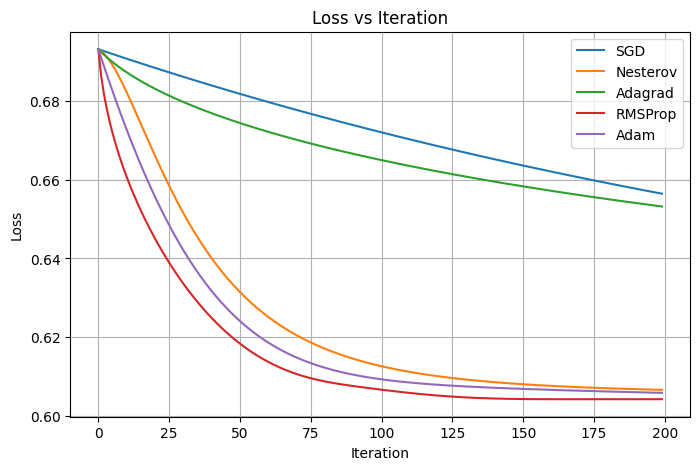

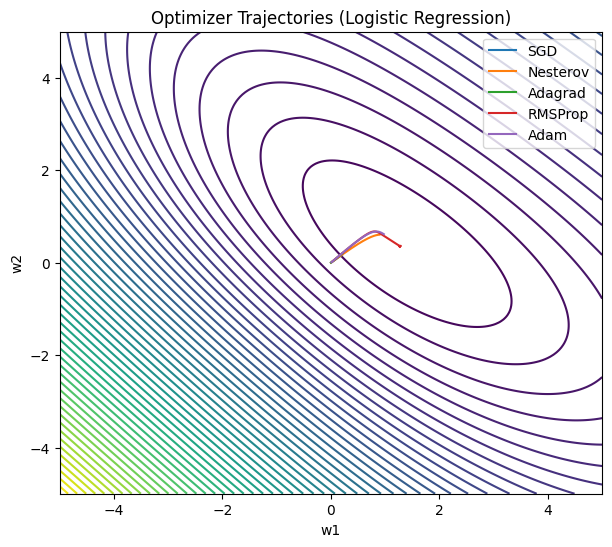

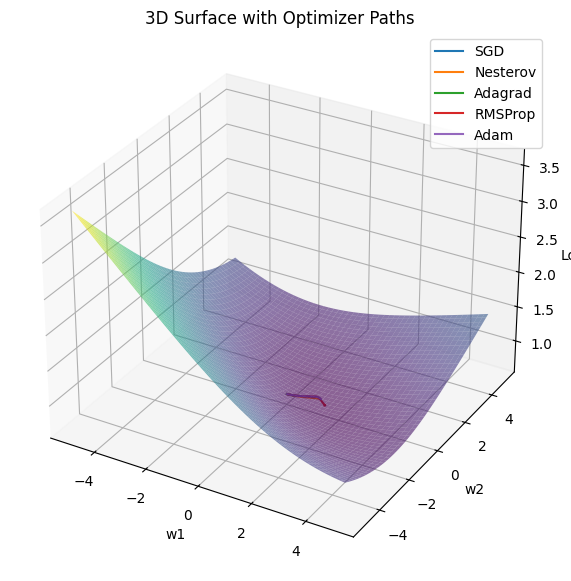

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# ==============================
# 1. Load Dataset from GitHub
# ==============================

url = "https://raw.githubusercontent.com/Jevidha/Applied-AI/main/csvjson.csv"
data = pd.read_csv(url)

X = data[['feature1','feature2']].values.astype(np.float32)
y = data['label'].values.astype(np.float32)

print("Dataset Shape:", X.shape)

# ==============================
# 2. Logistic Regression Model
# ==============================

def model(w, X):
    logits = tf.matmul(X, tf.reshape(w,(2,1)))
    return tf.sigmoid(logits)

# Binary Cross Entropy Loss
def loss_function(w):

    pred = model(w,X)

    y_true = tf.reshape(y,(-1,1))

    loss = -tf.reduce_mean(
        y_true * tf.math.log(pred + 1e-8) +
        (1-y_true)*tf.math.log(1-pred + 1e-8)
    )

    return loss

# ==============================
# 3. Optimization Function
# ==============================

def optimize(optimizer, iterations=200):

    w = tf.Variable([0.0,0.0], dtype=tf.float32)

    w_history=[]
    loss_history=[]

    for i in range(iterations):

        with tf.GradientTape() as tape:
            loss = loss_function(w)

        grads = tape.gradient(loss,[w])

        optimizer.apply_gradients(zip(grads,[w]))

        w_history.append(w.numpy().copy())
        loss_history.append(loss.numpy())

    return np.array(w_history), np.array(loss_history)

# ==============================
# 4. Define Optimizers
# ==============================

lr = 0.01

optimizers = {

    "SGD": tf.keras.optimizers.SGD(learning_rate=lr),

    "Nesterov": tf.keras.optimizers.SGD(
        learning_rate=lr,
        momentum=0.9,
        nesterov=True
    ),

    "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=lr),

    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=lr),

    "Adam": tf.keras.optimizers.Adam(learning_rate=lr)

}

results={}

for name,opt in optimizers.items():

    print("Running:",name)

    w_hist,loss_hist = optimize(opt)

    results[name]={"w":w_hist,"loss":loss_hist}

# ==============================
# 5. Loss vs Iteration Plot
# ==============================

plt.figure(figsize=(8,5))

for name in results:

    plt.plot(results[name]["loss"],label=name)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iteration")
plt.legend()
plt.grid()

plt.show()

# ==============================
# 6. Contour Plot
# ==============================

w1 = np.linspace(-5,5,200)
w2 = np.linspace(-5,5,200)

W1,W2 = np.meshgrid(w1,w2)

Z = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):

        w = tf.constant([W1[i,j],W2[i,j]],dtype=tf.float32)

        Z[i,j] = loss_function(w).numpy()

plt.figure(figsize=(7,6))

plt.contour(W1,W2,Z,levels=50)

for name in results:

    w_hist = results[name]["w"]

    plt.plot(w_hist[:,0],w_hist[:,1],label=name)

plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Optimizer Trajectories (Logistic Regression)")
plt.legend()

plt.show()

# ==============================
# 7. 3D Surface Plot
# ==============================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111,projection='3d')

ax.plot_surface(W1,W2,Z,cmap='viridis',alpha=0.6)

for name in results:

    w_hist = results[name]["w"]

    z_hist = []

    for w in w_hist:

        z_hist.append(loss_function(tf.constant(w)).numpy())

    ax.plot(w_hist[:,0],w_hist[:,1],z_hist,label=name)

ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_zlabel("Loss")
ax.set_title("3D Surface with Optimizer Paths")

ax.legend()

plt.show()